## Group 73 
### Students:
### - Adam Bailes
### - Jasser Dhaouadi
### - William Leblanc

# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**Answer**

The main objective of this project is to **build a model that can estimate the value of a house based on its features**, such as *size*, *number of rooms*, and *location*. From a **business perspective**, this is useful because it can help **automate the process of property valuation**, which is normally time-consuming and requires human appraisers. For companies like real estate platforms or banks, having a reliable model can help them **make faster and more consistent decisions** when pricing homes or evaluating loans.

In the context of this specific dataset, the model uses property characteristics such as *finished square footage*, *lot size*, *location coordinates*, *year built*, and *bathroom and bedroom counts* to estimate the assessed tax value (*taxvaluedollarcnt*). The dataset includes properties from **three California counties** (<u>as indicated by the fips variable</u>), making the model especially relevant for **regional real estate valuation** in those areas.

**1.2:**  How will your solution be used?


**Answer**

The solution would most likely be used as part of an **automated system that predicts house prices**. For example, a website like Zillow could use it <u>to show estimated property values to users</u>. Banks could also use it <u>when deciding whether to approve a mortgage</u>, since they need to know how much a property is worth. In general, the model would be used **whenever there is a need to quickly estimate property values** without doing a full manual appraisal.

Based on the **EDA**, the dataset shows a **wide range of property values**, which suggests the model would be practical in real-world scenarios where prices vary significantly. Additionally, such a model is especially useful in **high-volume markets**, where traditional appraisals can take a long time (<u>sometimes several weeks</u>), so having an automated estimate can help speed up decision-making.

**1.3:**  How should success (or failure) be measured?


**Answer**

Success should be measured both <u>technically and from a business point of view</u>. **Technically**, we can use metrics like **Root Mean Squared Error (RMSE)** or **Mean Squared Error (MSE)** to see how close our predictions are to the actual house prices. **Lower error means better performance**. In addition, we can use **Mean Absolute Percentage Error (MAPE)** to measure prediction error as a <u>percentage of the actual value</u>, which helps account for the wide range of property prices in the dataset. From a **business perspective**, success would mean that the model helps users or companies **make better decisions**, such as setting more accurate prices or reducing risk in lending. On the other hand, **failure** would be if the model makes **large errors**, especially for expensive houses, or if it gives **unreliable predictions** in certain areas.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
# Basic exploration
print("=== Dataset: HEAD ===")
df.head()

=== Dataset: HEAD ===


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
print("=== Dataset: INFO ===")
df.info()

=== Dataset: INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  flo

In [5]:
print("=== Dataset: SUMMARY ===")

summary = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.values,
    "Missing %": df.isnull().mean().values * 100,
    "Unique Values": df.nunique().values
})

summary

=== Dataset: SUMMARY ===


,Column,Dtype,Missing %,Unique Values
0,parcelid,int64,0.000000,77414
1,airconditioningtypeid,float64,67.779882,5
2,architecturalstyletypeid,float64,99.733292,5
3,basementsqft,float64,99.935578,43
4,bathroomcnt,float64,0.043807,22
5,bedroomcnt,float64,0.043807,16
6,buildingclasstypeid,float64,99.980673,2
7,buildingqualitytypeid,float64,35.823895,12
8,calculatedbathnbr,float64,0.837489,21
9,decktypeid,float64,99.208895,1


**Key Findings & Interpretation**

- **Dataset Overview:**
    - Rows: 77,613
    - Columns: 55
    - <u>Interpretation:</u>
        - Mostly numerical (int64/float64) with a few categorical (object/str) columns

- **Target Variable: taxvaluedollarcnt**
    - Type: Continuous (float)
    - Missing: ~0.045% (very low)
    - Unique values: ~50,949 (highly granular)
    - <u>Interpretation:</u>
        - This is clearly a **regression** problem
        - Target is high-quality (almost no missing values) -> good for modeling


- **Feature Types:**

    - **Numerical Features** (Majority)
        - Examples: *bathroomcnt, bedroomcnt, yearbuilt, calculatedfinishedsquarefeet, lotsizesquarefeet* ...
        - These are **very useful** for prediction

    - **Categorical Features** (encoded as numbers or objects/str)
        - Examples:
            - *propertycountylandusecode* (str)
            - *propertyzoningdesc* (str)
            - *heatingorsystemtypeid* (encoded category)
        - These will need:
            - Encoding (Ordinal / One-hot)
            - Careful handling if high cardinality

- **Missing Values Analysis:** (CRITICAL) </br>
We can group features into 4 categories:
    - **Low Missing (<5%)** -> Keep
        - These features are <u>high quality</u>
        - Example: 
            - *bathroomcnt* (~0.04%)
            - *bedroomcnt* (~0.04%)
            - *yearbuilt* (~0.39%)
            - *calculatedfinishedsquarefeet* (~0.30%)
            - *regionidzip* (~0.1%)
            - *taxvaluedollarcnt* (~0.045%) [**target**]
    
    - **Moderate Missing (10–40%)** -> Careful Use
        - These features still carry signal but <u>require preprocessing</u> (impute missing values)
        - Examples:
            - *lotsizesquarefeet* (~10.7%)
            - *unitcnt* (~34.7%)
            - *propertyzoningdesc* (~35.0%)
            - *buildingqualitytypeid* (~35.8%)
            - *heatingorsystemtypeid* (~36.1%)
    
    - **High Missing (40–90%)** -> Selective Use
        - These features are <u> risky but may still be useful</u>.
        - Examples:
            - *garagecarcnt* (~67.1%)
            - *garagetotalsqft* (~67.1%)
            - *poolcnt* (~79.2%)
            - *numberofstories* (~77.3%)
            - *regionidneighborhood* (~60.1%)
            - *threequarterbathnbr* (~87.0%)
        - Strategy:
            - Use domain intuition: *garagecarcnt* may still be valuable
            - Options:
                - Impute + add missing flag
                - Convert to binary indicators (has garage: yes/no)
                - Drop if: No improvement in model performance
    
    - **Extremely High Missing (>90%)** -> Drop (Mostly)
        - These features contain <u>too little information</u>.
        - **Likely not useful** & Candidates for dropping
        - Examples:
            - *basementsqft* (~99.94%)
            - *architecturalstyletypeid* (~99.73%)
            - *finishedsquarefeet13* (~99.95%)
            - *yardbuildingsqft26* (~99.91%)
            - *storytypeid* (~99.94%)
            - *fireplaceflag* (~99.78%)
            - *hashottuborspa* (~98.0%)

- **Unique Values Insight**
    - **High Cardinality** (Potential Issues)
        - Examples:
            - *parcelid* (~77k unique) -> ID -> to drop
            - *latitude*, *longitude* -> useful but need transformation
            - *censustractandblock* -> too granular

    - **Low Cardinality** (Good for categorical)
         - Examples:
            - *fips* (3 values)
            - *propertylandusetypeid* (13 values)
            - *regionidcounty* (3 values)


- **Apparent Feature Usefulness**
    - **Strong Predictors** (intuitively)
        - *calculatedfinishedsquarefeet*
        - *bathroomcnt*, *bedroomcnt*
        - *yearbuilt*
        - location features (zip, lat/long)

    - **Weak / Noisy**
        - *assessmentyear* (only 1 unique value -> useless)
        - *hashottuborspa*, *fireplaceflag* (almost all missing)

    - **Likely Drop Candidates**
        - Features with:
            - too many missing values 
            - 1 unique value
            - ID-like behavior



In [6]:
# Identify categorical columns
# 1. Object type
categorical_object = df.select_dtypes(include=['object', 'str']).columns.tolist()

# 2. Numeric columns with low unique values (likely encoded categories)
categorical_numeric = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if df[col].nunique() < 20]

# Display results
print("Categorical (object/str) columns:")
print(categorical_object)

print("\n TO INVESTIGATE: Possible Categorical (numeric encoded) columns (nunique < 20):")
print(categorical_numeric)


Categorical (object/str) columns:
['hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag']

 TO INVESTIGATE: Possible Categorical (numeric encoded) columns (nunique < 20):
['airconditioningtypeid', 'architecturalstyletypeid', 'bedroomcnt', 'buildingclasstypeid', 'buildingqualitytypeid', 'decktypeid', 'finishedsquarefeet13', 'fips', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'heatingorsystemtypeid', 'poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertylandusetypeid', 'regionidcounty', 'roomcnt', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'unitcnt', 'numberofstories', 'assessmentyear', 'taxdelinquencyyear']


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Categorical features include:

- **True Categorical (object/str type)**
    - These are clearly categorical (they <u>represent labels or text categories</u>):
        - *propertycountylandusecode*
        - *propertyzoningdesc*
        - *hashottuborspa*
        - *fireplaceflag*
        - *taxdelinquencyflag*

- **Encoded Categorical (Numeric IDs)**
    - These are stored as numbers but <u>represent categories, not quantities</u>:
    - These should **NOT** be treated as continuous numbers (Treating them as numeric would mislead the model):
        - *airconditioningtypeid*
        - *architecturalstyletypeid*
        - *buildingclasstypeid*
        - *buildingqualitytypeid*
        - *decktypeid*
        - *fips*
        - *heatingorsystemtypeid*
        - *pooltypeid10*
        - *pooltypeid2*
        - *pooltypeid7*
        - *propertylandusetypeid*
        - *regionidcity*
        - *regionidcounty*
        - *regionidneighborhood*
        - *regionidzip*
        - *storytypeid*
        - *typeconstructiontypeid*

- **Binary / Indicator-like Categorical**
    - These behave like categorical variables with few values:
        - *poolcnt* (can also be treated as numeric depending on use)
        - *fireplacecnt* (can also be treated as numeric depending on use)



**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Yes, some features appear **irrelevant for predicting property value**.

- **Examples:**
    - *parcelid*
    - *assessmentyear*

- **Reasoning:**
    - *parcelid*:
        - Unique identifier for each property
        - Contains no predictive signal -> purely an ID
        - Should be dropped

    - *assessmentyear*:
        - Only 1 unique value (2016)
        - No variation -> cannot help prediction
        - Adds no information

- **Conclusion:**
    - These features are useless for modeling because they:
        - Do not describe property characteristics
        - Do not vary meaningfully

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Yes, some features are **too sparse to be useful**.

- **Example:**
    - *basementsqft* (~99.94% missing)

- **Reasoning:**
    - Almost all values are missing
    - Very few observations available -> unreliable patterns
    - Imputation would introduce **too much noise**

- **Other similar examples:**
    - *architecturalstyletypeid*
    - *finishedsquarefeet13*
    - *yardbuildingsqft26*
    - *storytypeid*

- **Conclusion:**
    - Features with **>90% missing values** are generally:
        - Not reliable
        - Better to drop

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Yes, some features are problematic due to **too many or too few unique values**.

- **Case 1: Too Many Unique Values (High Cardinality)**
    - **Example:**
        - *parcelid* (~77k unique)
    - **Reasoning:**
        - Almost every value is unique
        - Acts like an ID, not a feature
        - Cannot generalize patterns -> **overfitting risk**

- **Case 2: Too Few Unique Values (No Variability)**
    - **Example:**
        - *assessmentyear* (1 unique value)
    - **Reasoning:**
        - No variation -> no predictive power

- **Case 3: Very High Cardinality Categorical**
    - **Example:**
        - *propertyzoningdesc* (~1900 unique values)
    - **Reasoning:**
        - Too many categories -> difficult to encode (**impractical for modeling**)
        - May introduce noise and sparsity
        - Requires special handling or removal

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

**Histograms for All Numerical Features**

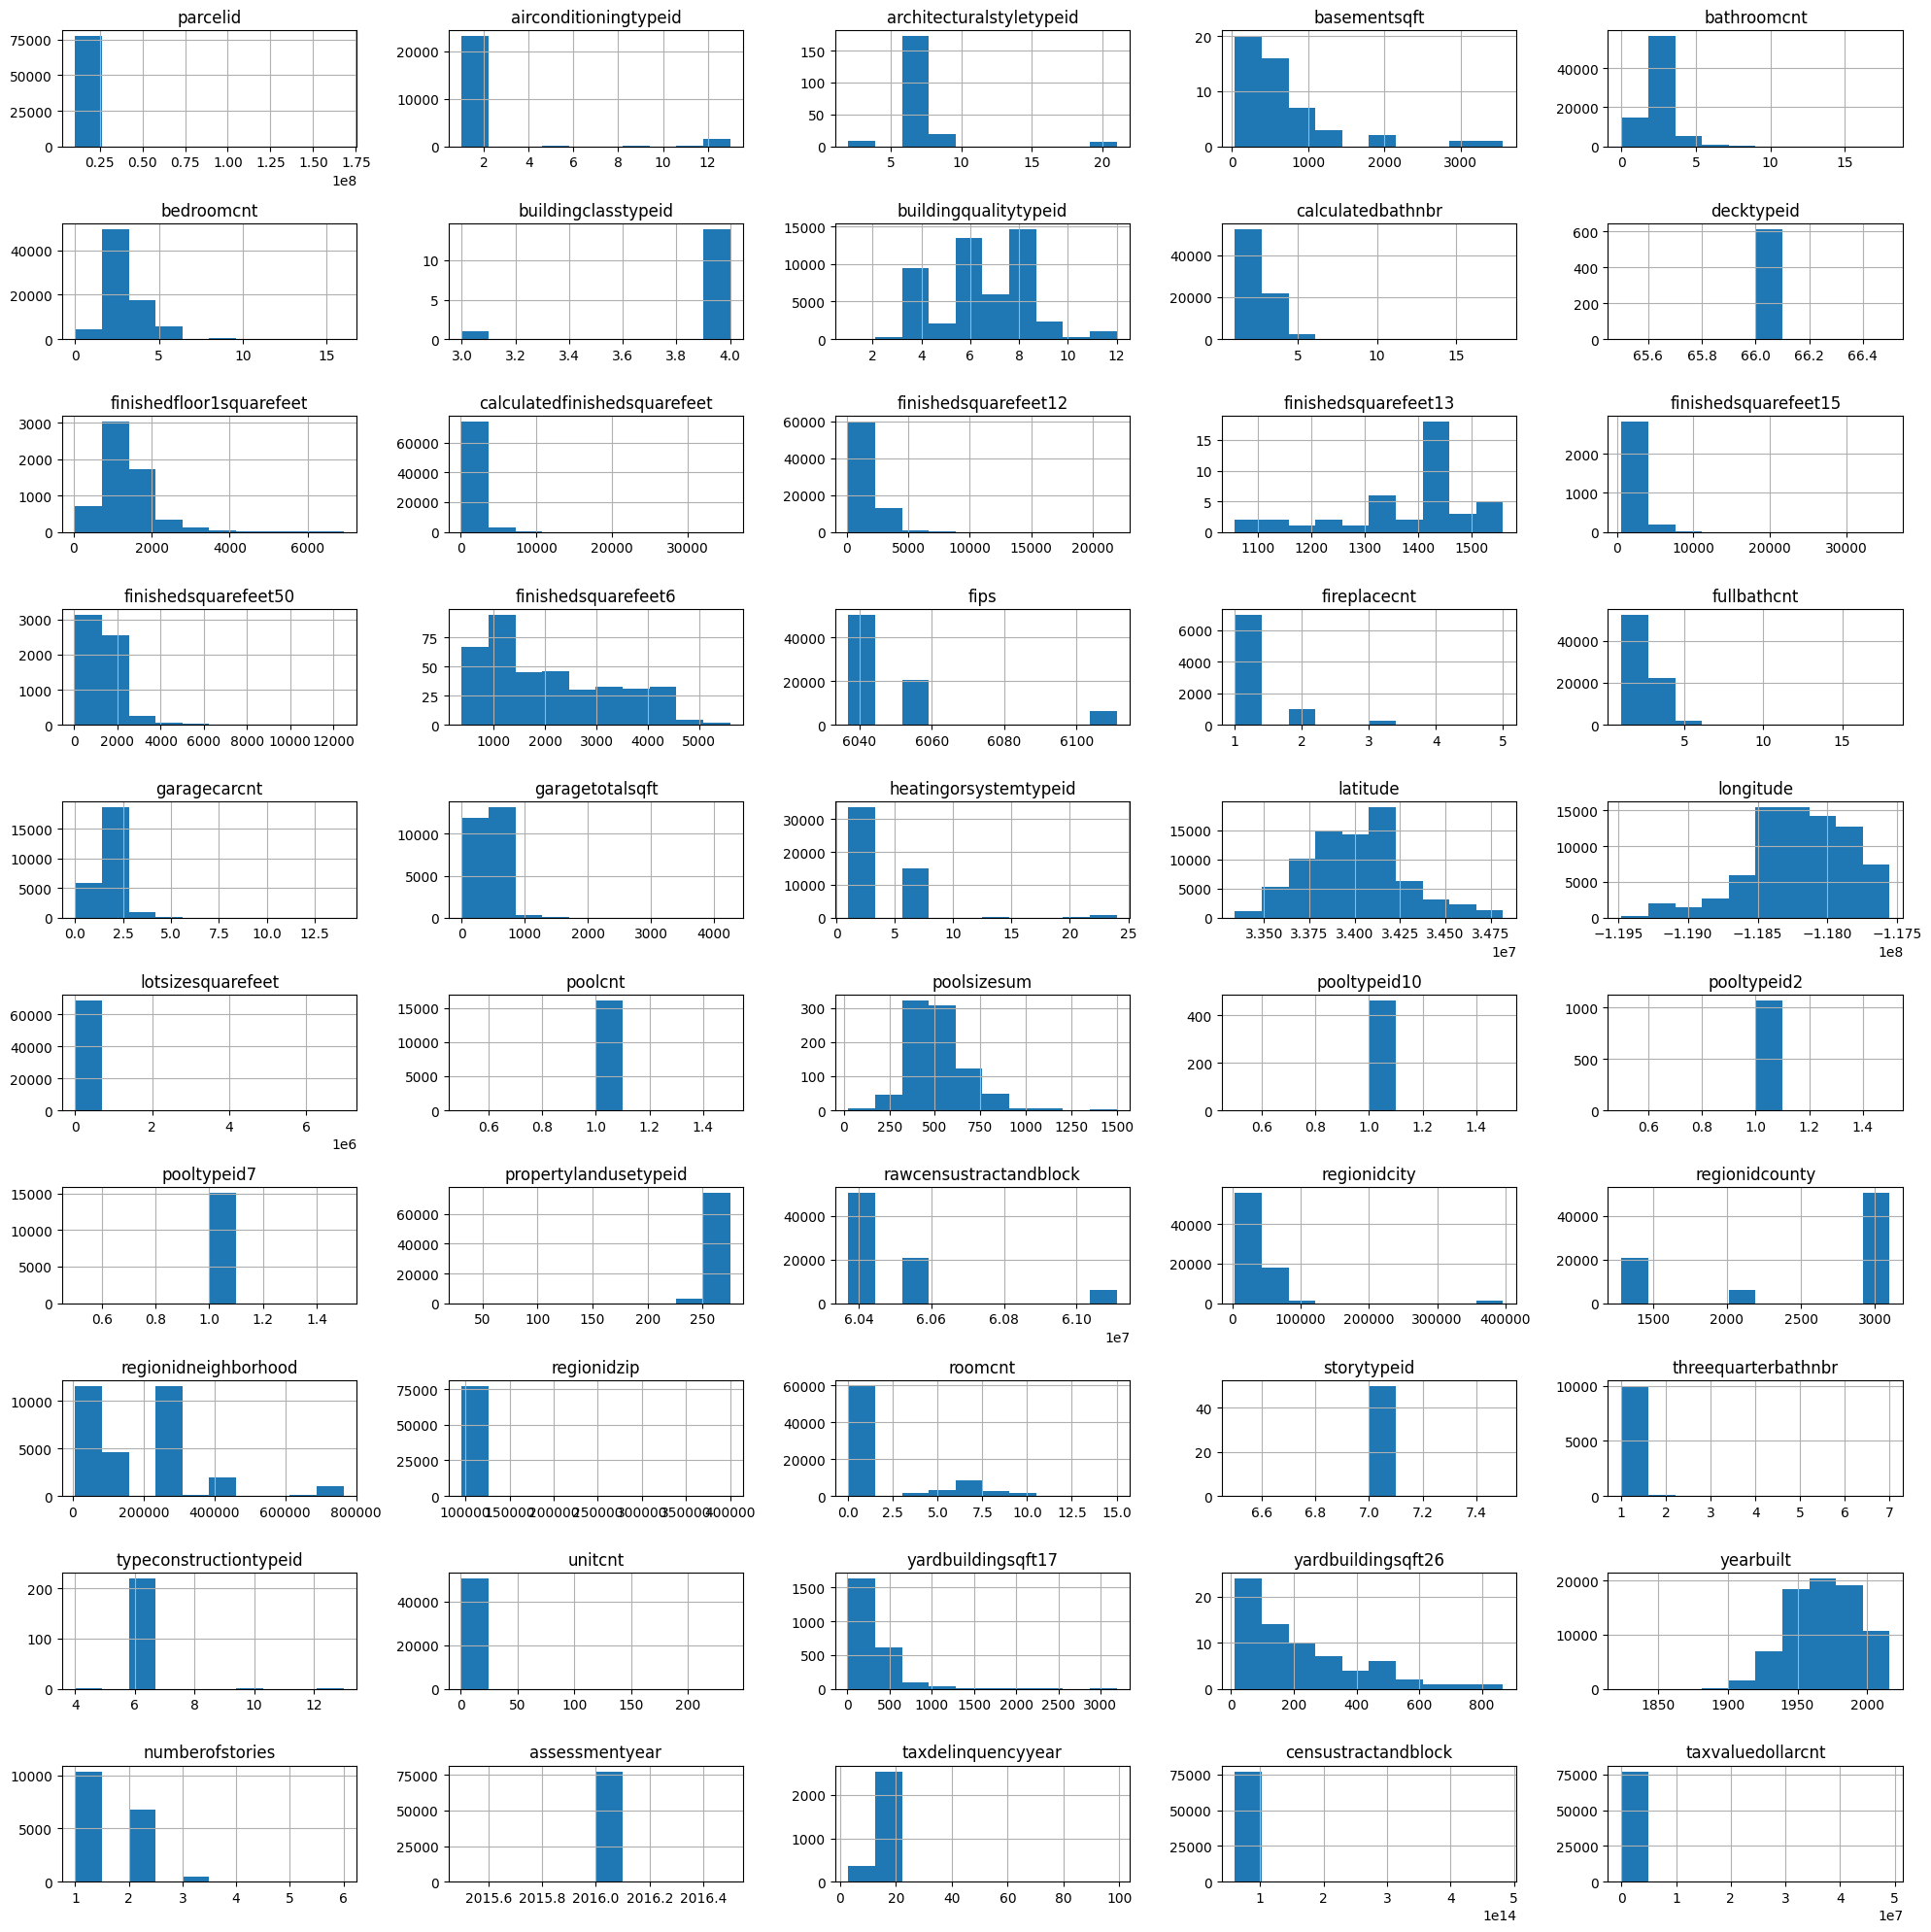

In [7]:
# =============================
# 1. Histograms for all features
# =============================
df.hist(figsize=(20, 20), layout=(-1, 5))
plt.tight_layout()
plt.show()

**Observation & Interpretation**

- Many features are **right-skewed**:
    - Examples:
        - *taxvaluedollarcnt* (target)
        - *calculatedfinishedsquarefeet*
        - *lotsizesquarefeet*
        - *finishedsquarefeet12*
    - Interpretation:
        - Most properties have **lower values**, with a few very large ones (typical in real estate data)
        - Suggests:
            - Possible **log transformation**
            - Non-normal distribution

- Several features have **extreme outliers**
    - Examples:
        - *taxvaluedollarcnt* : very expensive properties
        - *calculatedfinishedsquarefeet* : extremely large houses
        - *bathroomcnt* : unusually high values (e.g., >10)
        - *garagetotalsqft* : very large garages
    - Interpretation: 
        - Outliers may:
            - Distort model training
            - Affect mean-based methods
        - May require:
            - **capping or removal**


- Some features show **sparse distributions**
    - Examples:
        - *basementsqft*
        - *yardbuildingsqft26*
        - *finishedsquarefeet13*
        - *decktypeid*
    - Interpretation: 
        - Most values are missing or zero (Very few non-zero observations)
        - These features:
            - Carry **little usable information**
            - Are good candidates for **dropping**

- Some features (example: *assessmentyear*) **show no variability**

**Individual Feature Visualizations (4 Total)**

**Target: taxvaluedollarcnt**

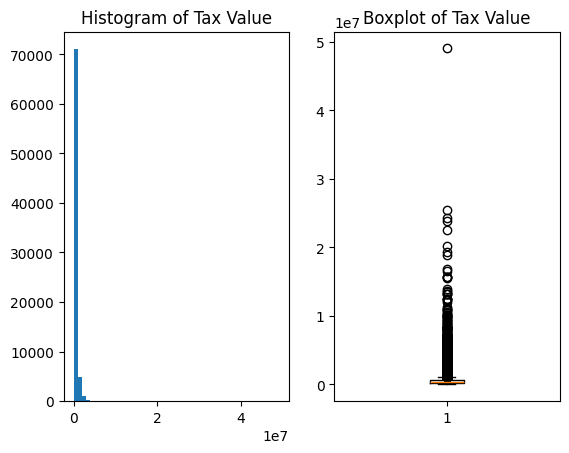

In [8]:
# =============================
# 2. Target variable visualization
# =============================
fig, ax = plt.subplots(1, 2)
ax[0].hist(df['taxvaluedollarcnt'].dropna(), bins=50)
ax[0].set_title('Histogram of Tax Value')

ax[1].boxplot(df['taxvaluedollarcnt'].dropna())
ax[1].set_title('Boxplot of Tax Value')

plt.show()

**Observations:**
- Highly right-skewed distribution
- Majority of homes have lower values
- Few properties have very large values (possible outliers)

**Insight:**
- May need:
    - **log** transformation or **outlier handling**

**Feature 1: calculatedfinishedsquarefeet**

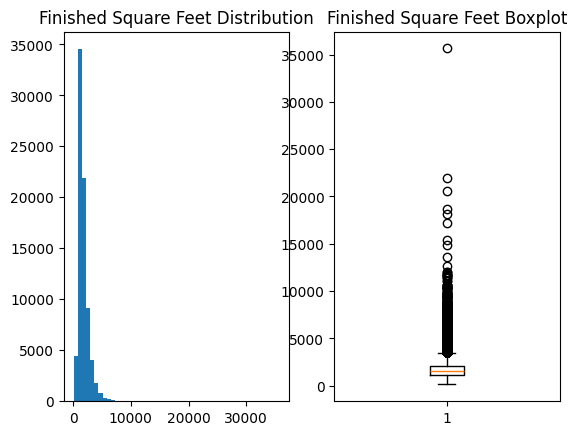

In [9]:
# =============================
# 3. Feature 1: calculatedfinishedsquarefeet
# =============================
fig, ax = plt.subplots(1, 2)
ax[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=50)
ax[0].set_title('Finished Square Feet Distribution')

ax[1].boxplot(df['calculatedfinishedsquarefeet'].dropna())
ax[1].set_title('Finished Square Feet Boxplot')

plt.show()

**Observations:**
- Strong <u>right skew</u>
- Most homes are <u>small–medium sized</u>
- Large outliers to consider (very big houses)

**Insight:**
- Likely a strong predictor
- May benefit from: scaling / transformation

**Feature 2: bathroomcnt**

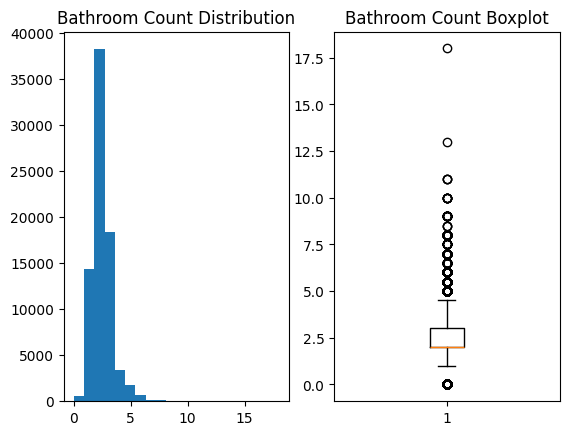

In [10]:
# =============================
# 4. Feature 2: bathroomcnt
# =============================
fig, ax = plt.subplots(1, 2)
ax[0].hist(df['bathroomcnt'].dropna(), bins=20)
ax[0].set_title('Bathroom Count Distribution')

ax[1].boxplot(df['bathroomcnt'].dropna())
ax[1].set_title('Bathroom Count Boxplot')

plt.show()

**Observations:**
- Most values between 1–4 bathrooms
- Clear discrete distribution
- Some extreme values (outliers up to ~18)

**Insight:**
- Useful feature
- Outliers may need: **capping or filtering**

**Feature 3: buildingqualitytypeid (Categorical)**

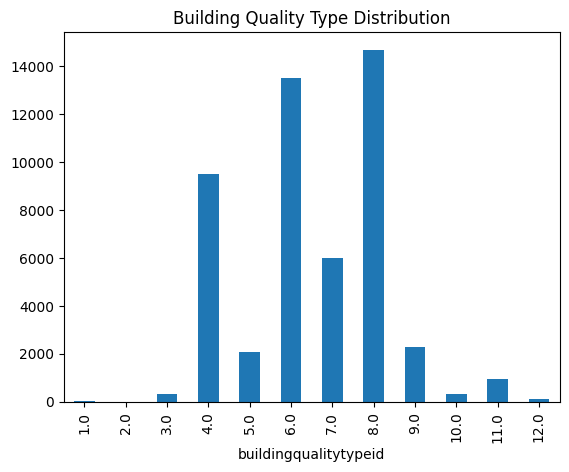

In [11]:
# =============================
# 5. Feature 3: buildingqualitytypeid (categorical)
# =============================
# Bar plot
df['buildingqualitytypeid'].value_counts().sort_index().plot(kind='bar')
plt.title('Building Quality Type Distribution')
plt.show()

**Observations:**
- Uneven distribution across categories
- Some categories dominate (e.g., 6, 7, 8)
- Others are rare

**Insight:**
- Important categorical feature
- May require:
    - encoding
    - grouping rare categories

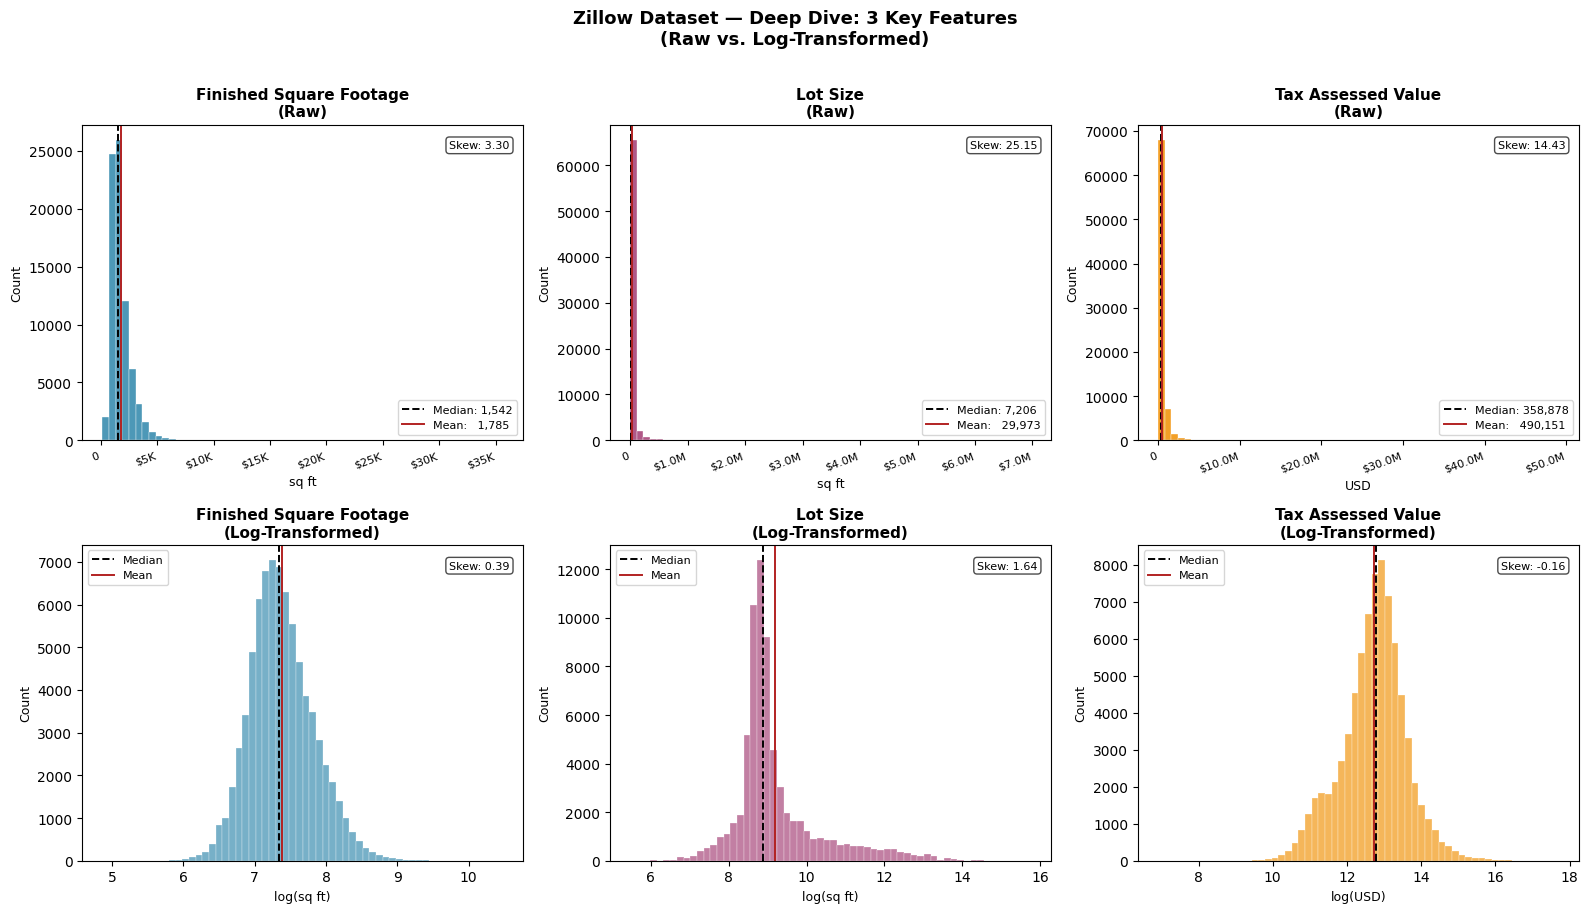

In [12]:

# Histogram of log conversion of 2 selected features and the target


features = {
    'calculatedfinishedsquarefeet': {
        'label': 'Finished Square Footage',
        'unit': 'sq ft',
        'color': '#2E86AB'
    },
    'lotsizesquarefeet': {
        'label': 'Lot Size',
        'unit': 'sq ft',
        'color': '#A23B72'
    },
    'taxvaluedollarcnt': {
        'label': 'Tax Assessed Value',
        'unit': 'USD',
        'color': '#F18F01'
    }
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col_idx, (col, meta) in enumerate(features.items()):
    data = df[col].dropna()

    # ── Row 1: Raw distribution ──────────────────────────────
    ax = axes[0, col_idx]
    ax.hist(data, bins=60, color=meta['color'], edgecolor='white', linewidth=0.3,
            alpha=0.85)

    # Mark median and mean
    median_val = data.median()
    mean_val   = data.mean()
    ax.axvline(median_val, color='black',     linestyle='--', linewidth=1.4,
               label=f'Median: {median_val:,.0f}')
    ax.axvline(mean_val,   color='firebrick', linestyle='-',  linewidth=1.4,
               label=f'Mean:   {mean_val:,.0f}')

    ax.set_title(f'{meta["label"]}\n(Raw)', fontsize=11, fontweight='bold')
    ax.set_xlabel(meta['unit'], fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x/1e6:.1f}M' if (meta['unit']=='USD' and abs(x)>=1e6) else
                      f'${x/1e3:.0f}K' if (meta['unit']=='USD' and abs(x)>=1e3) else
                      f'{x/1e3:.0f}K'  if abs(x)>=1e3 else f'{x:.0f}'
    ))
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)

    # ── Row 2: Log-transformed distribution ──────────────────
    ax2 = axes[1, col_idx]
    log_data = np.log1p(data[data > 0])  # log1p handles near-zero values safely
    ax2.hist(log_data, bins=60, color=meta['color'], edgecolor='white',
             linewidth=0.3, alpha=0.65)
    ax2.axvline(log_data.median(), color='black',     linestyle='--', linewidth=1.4,
                label='Median')
    ax2.axvline(log_data.mean(),   color='firebrick', linestyle='-',  linewidth=1.4,
                label='Mean')
    ax2.set_title(f'{meta["label"]}\n(Log-Transformed)', fontsize=11, fontweight='bold')
    ax2.set_xlabel(f'log({meta["unit"]})', fontsize=9)
    ax2.set_ylabel('Count', fontsize=9)
    ax2.legend(fontsize=8)

    # Annotation: skewness
    skew_raw = data.skew()
    skew_log = log_data.skew()
    ax.text(0.97, 0.95, f'Skew: {skew_raw:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax2.text(0.97, 0.95, f'Skew: {skew_log:.2f}', transform=ax2.transAxes,
             ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

fig.suptitle('Zillow Dataset — Deep Dive: 3 Key Features\n(Raw vs. Log-Transformed)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
for col in ['calculatedfinishedsquarefeet', 'lotsizesquarefeet', 'taxvaluedollarcnt']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    n_outliers = df[(df[col] > upper) | (df[col] < lower)][col].count()
    mean_val   = df[col].mean()
    median_val = df[col].median()
    print(f"{col}")
    print(f"  Mean:           {mean_val:,.0f}")
    print(f"  Median:         {median_val:,.0f}")
    print(f"  Lower bound:    {lower:,.0f}")
    print(f"  Upper bound:    {upper:,.0f}")
    print(f"  No. outliers:   {n_outliers} ({n_outliers/df[col].count()*100:.1f}%)\n")

calculatedfinishedsquarefeet
  Mean:           1,785
  Median:         1,542
  Lower bound:    -213
  Upper bound:    3,507
  No. outliers:   4006 (5.2%)

lotsizesquarefeet
  Mean:           29,973
  Median:         7,206
  Lower bound:    -3,506
  Upper bound:    21,042
  No. outliers:   11408 (16.5%)

taxvaluedollarcnt
  Mean:           490,151
  Median:         358,878
  Lower bound:    -336,254
  Upper bound:    1,112,152
  No. outliers:   5186 (6.7%)



#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


### Answer:

From the exploratory analysis, several important patterns emerged in the dataset. The target variable, *taxvaluedollarcnt*, as well as key numerical features like *calculatedfinishedsquarefeet* and *lotsizesquarefeet*, exhibit **strong right-skewed (approximately exponential-like) distributions**, where most properties have relatively low values and a small number have extremely high values. This skewness indicates that **transformations such as logarithmic scaling may be beneficial for modeling**. A major issue observed across multiple features is the presence of **extreme outliers**, such as unusually **large property values, square footage, and high bathroom counts**, which could negatively impact model performance if not handled properly. Additionally, several features show **sparse distributions with many missing or near-zero values** (e.g., *basementsqft*, *yardbuildingsqft26*), suggesting they may not contribute meaningful information. The feature *buildingqualitytypeid* was particularly interesting due to its **categorical and imbalanced distribution**, with certain categories dominating, indicating potential importance but also the need for careful encoding. Overall, the features chosen were selected because they represent different data types (continuous, discrete, categorical) and reveal key challenges in the dataset, including skewness, outliers, and missing data, all of which are critical considerations for building a robust predictive model

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [13]:
# Part 3.A: Drop features judged unsuitable for regression

drop_3a_cols = [
    'parcelid',
    'rawcensustractandblock',
    'censustractandblock',
    'regionidzip',
    'regionidcity',
    'regionidneighborhood',
    'fips',
    'propertycountylandusecode',
    'assessmentyear',
    'finishedsquarefeet12',
    'calculatedbathnbr',
    'fullbathcnt'
]

def drop_unsuitable_features(data, cols_to_drop):
    data_copy = data.copy()
    return data_copy.drop(columns=cols_to_drop, errors='ignore')

df_3a = drop_unsuitable_features(df, drop_3a_cols)

print("Original shape:", df.shape)
print("Shape after Part 3.A:", df_3a.shape)
print("\nDropped columns:")
print(drop_3a_cols)

Original shape: (77613, 55)
Shape after Part 3.A: (77613, 43)

Dropped columns:
['parcelid', 'rawcensustractandblock', 'censustractandblock', 'regionidzip', 'regionidcity', 'regionidneighborhood', 'fips', 'propertycountylandusecode', 'assessmentyear', 'finishedsquarefeet12', 'calculatedbathnbr', 'fullbathcnt']


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


For Part 3.A, our group **dropped features that did not seem very useful for the regression task**. Some of these variables were mostly **identifiers or administrative codes instead of actual property characteristics**. For example, *parcelid* was dropped because it is only a record ID and does not tell us anything meaningful about the home itself. Variables such as *rawcensustractandblock*, *censustractandblock*, *regionidzip*, *regionidcity*, *regionidneighborhood*, *fips*, and *propertycountylandusecode* were also **removed because they mainly act as location or county coding variables, while latitude and longitude already provide more direct location information**. *assessmentyear* was dropped because it **does not vary across the dataset**. Our group also removed *finishedsquarefeet12*, *calculatedbathnbr*, and *fullbathcnt* because they **overlap with broader variables** that already capture similar information.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [14]:
# Part 3.B: Drop features with too many null values

missing_pct = df_3a.isnull().mean()

high_missing = missing_pct[missing_pct > 0.70].sort_values(ascending=False)

print("Features with more than 70% missing values:\n")
print(high_missing)

drop_3b_cols = list(high_missing.index)


# ======================================================
# Part 3B: Drop features with too many null values
# ======================================================
def drop_high_missing_features(df, threshold=0.70):
    df_tmp = df.copy()
    missing_pct = df_tmp.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
    return df_tmp.drop(columns=cols_to_drop, errors='ignore'), cols_to_drop

df_3b, _ = drop_high_missing_features(df_3a, threshold=0.70)

print("\nOriginal shape after 3.A:", df_3a.shape)
print("Shape after 3.B:", df_3b.shape)
print("\nDropped columns:")
print(drop_3b_cols)

Features with more than 70% missing values:

buildingclasstypeid         0.999807
finishedsquarefeet13        0.999459
basementsqft                0.999356
storytypeid                 0.999356
yardbuildingsqft26          0.999098
fireplaceflag               0.997784
architecturalstyletypeid    0.997333
typeconstructiontypeid      0.997127
finishedsquarefeet6         0.995027
pooltypeid10                0.994009
decktypeid                  0.992089
poolsizesum                 0.988803
pooltypeid2                 0.986162
hashottuborspa              0.980171
yardbuildingsqft17          0.969168
taxdelinquencyflag          0.962635
taxdelinquencyyear          0.962635
finishedsquarefeet15        0.960999
finishedfloor1squarefeet    0.922217
finishedsquarefeet50        0.922217
fireplacecnt                0.893201
threequarterbathnbr         0.869790
pooltypeid7                 0.805716
poolcnt                     0.791607
numberofstories             0.773247
dtype: float64

Original shape

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



For Part 3.B, our group decided to **drop features with more than 70% missing values**. We picked **70%** because there was **a pretty clear break around that point in the missing value results**. Features above that level were missing most of their data, so keeping them would mean doing a lot of imputation without having much real information to work with. A lot of those variables also looked weak in other ways, since several were sparse, near-constant, or only had a small number of actual values. Because of that, it made more sense to drop them than to keep trying to fill in so much missing data.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [15]:
# ==========================================================================
# Part 3C: Drop problematic samples
# Rules used:
# 1. Drop rows with missing target
# 2. Drop rows with too many missing values across remaining features
# ==========================================================================
def drop_problematic_samples(df, target_col='taxvaluedollarcnt', row_missing_threshold=0.30):
    df_tmp = df.copy()
    
    # 1. Drop rows with null target
    null_target_mask = df_tmp[target_col].isnull()
    n_null_target = int(null_target_mask.sum())
    df_tmp = df_tmp.loc[~null_target_mask].copy()
    
    # 2. Drop rows with too many missing values
    row_missing_pct = df_tmp.isnull().mean(axis=1)
    high_row_missing_mask = row_missing_pct > row_missing_threshold
    n_high_row_missing = int(high_row_missing_mask.sum())
    df_tmp = df_tmp.loc[~high_row_missing_mask].copy()
    
    
    summary = {
        "rows_with_null_target_dropped": n_null_target,
        "rows_with_too_many_nulls_dropped": n_high_row_missing,
        "final_shape": df_tmp.shape
    }
    
    return df_tmp, summary


df_3c, sample_drop_summary = drop_problematic_samples(df_3b, target_col='taxvaluedollarcnt', row_missing_threshold=0.30)

sample_drop_summary

{'rows_with_null_target_dropped': 35,
 'rows_with_too_many_nulls_dropped': 6787,
 'final_shape': (70791, 18)}

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


For Part 3.C, our group dropped samples that looked problematic because they were missing too much important information. First, we **removed rows where *taxvaluedollarcnt* (target variable) was missing**, since those samples cannot be used in a regression task. After that, we looked at how much data was still missing in each remaining row and **dropped samples with more than 30% missing values**. We chose this cutoff because rows missing a large share of their remaining features would need a lot of imputation and would likely add more noise than useful information. We did **NOT** automatically remove target outliers at this stage, since <u>unusually high or low home values may still be valid observations in a housing dataset</u>.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [16]:
# Part 3.D: Impute remaining missing values

# Check what is still missing
print("Missing values before imputation:\n")
print(df_3c.isnull().sum()[df_3c.isnull().sum() > 0].sort_values(ascending=False))

# Separate numeric and categorical columns
num_cols = df_3c.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_3c.select_dtypes(include=['object', 'str']).columns.tolist()

# Imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Create new dataframe
df_3d = df_3c.copy()

# Impute numeric columns
df_3d[num_cols] = num_imputer.fit_transform(df_3d[num_cols])

# Impute categorical columns
if len(cat_cols) > 0:
    df_3d[cat_cols] = cat_imputer.fit_transform(df_3d[cat_cols])

# Final check
print("\nMissing values after imputation:", df_3d.isnull().sum().sum())
print("\nShape after imputation:", df_3d.shape)

Missing values before imputation:

garagetotalsqft                 50597
garagecarcnt                    50597
airconditioningtypeid           45890
heatingorsystemtypeid           21480
buildingqualitytypeid           20987
propertyzoningdesc              20413
unitcnt                         20227
lotsizesquarefeet                2215
yearbuilt                          30
calculatedfinishedsquarefeet        2
dtype: int64

Missing values after imputation: 0

Shape after imputation: (70791, 18)


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


For Part 3.D, our group used **different imputation methods depending on the type of feature**. **Numeric** columns were filled with the **median** because many of them were skewed and had outliers, so the median was a better choice than the mean. **Categorical** columns were filled with the **most common value** since that was a simple way to handle the missing entries. We used imputation here so we could keep the remaining data and make sure no null values were left in the dataset.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [17]:
# 3.E: Encode categorical features 
cat_cols = df_3d.select_dtypes(include=['object', 'str']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

df_3e = df_3d.copy()

if len(cat_cols) > 0:
    encoder = OrdinalEncoder()
    df_3e[cat_cols] = encoder.fit_transform(df_3e[cat_cols])

print("\nFinal shape after encoding:", df_3e.shape)
print("\nRemaining object columns:")
print(df_3e.select_dtypes(include=['object']).columns.tolist())

Categorical columns to encode: ['propertyzoningdesc']

Final shape after encoding: (70791, 18)

Remaining object columns:
[]


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

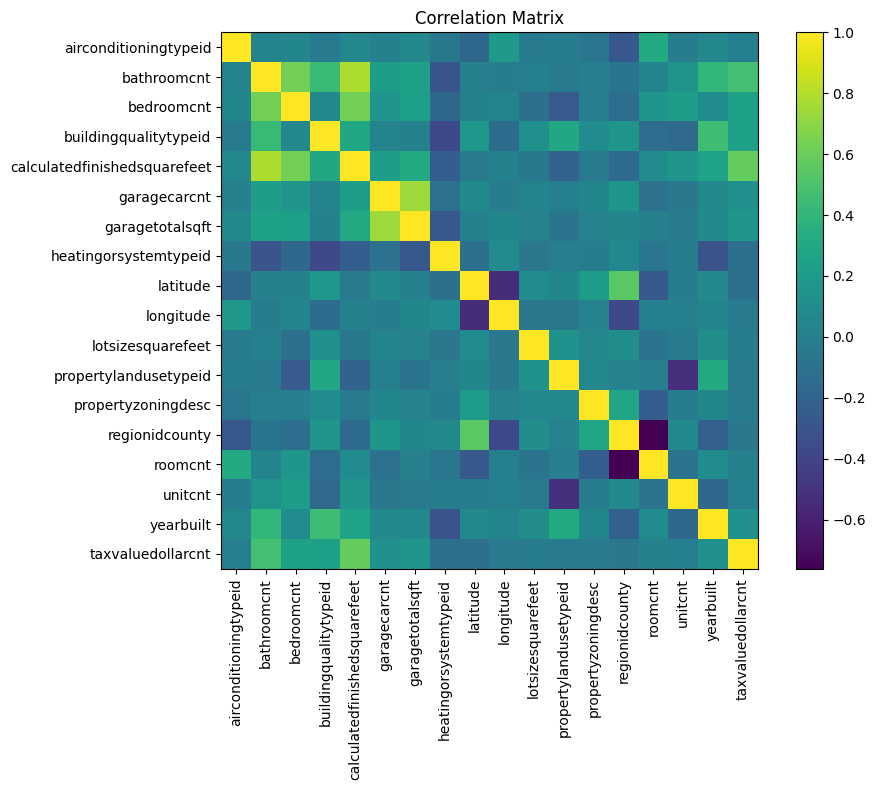

Top correlations with target:
taxvaluedollarcnt               1.000000
calculatedfinishedsquarefeet    0.584844
bathroomcnt                     0.475630
bedroomcnt                      0.245289
buildingqualitytypeid           0.239027
garagetotalsqft                 0.160584
yearbuilt                       0.132079
garagecarcnt                    0.129308
roomcnt                         0.004506
unitcnt                         0.001868
airconditioningtypeid           0.001581
lotsizesquarefeet              -0.023038
propertylandusetypeid          -0.026419
longitude                      -0.033368
propertyzoningdesc             -0.037038
regionidcounty                 -0.062673
heatingorsystemtypeid          -0.107767
latitude                       -0.112067
Name: taxvaluedollarcnt, dtype: float64


In [18]:

# copy the preprocessed dataset from previous task
df_4a = df_3e.copy()

# Separate features and target
X = df_4a.drop(columns=['taxvaluedollarcnt'])
y = df_4a['taxvaluedollarcnt']

# =============================
# 1. Correlation Matrix
# =============================
corr_matrix = df_4a.corr()

plt.figure(figsize=(10, 8)) 
plt.imshow(corr_matrix)
plt.title("Correlation Matrix")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.tight_layout()
plt.show()

# Show top correlations with target
target_corr = corr_matrix['taxvaluedollarcnt'].sort_values(ascending=False)
print("Top correlations with target:")
print(target_corr)




F-statistics:
                         feature       f_score
4   calculatedfinishedsquarefeet  36800.019016
1                    bathroomcnt  20696.104185
2                     bedroomcnt   4531.823269
3          buildingqualitytypeid   4289.546126
6                garagetotalsqft   1873.781496
16                     yearbuilt   1256.834590
5                   garagecarcnt   1203.765871
8                       latitude    900.350236
7          heatingorsystemtypeid    831.781157
13                regionidcounty    279.145499
12            propertyzoningdesc     97.241702
9                      longitude     78.906663
11         propertylandusetypeid     49.442447
10             lotsizesquarefeet     37.590775
14                       roomcnt      1.437618
15                       unitcnt      0.246993
0          airconditioningtypeid      0.176886


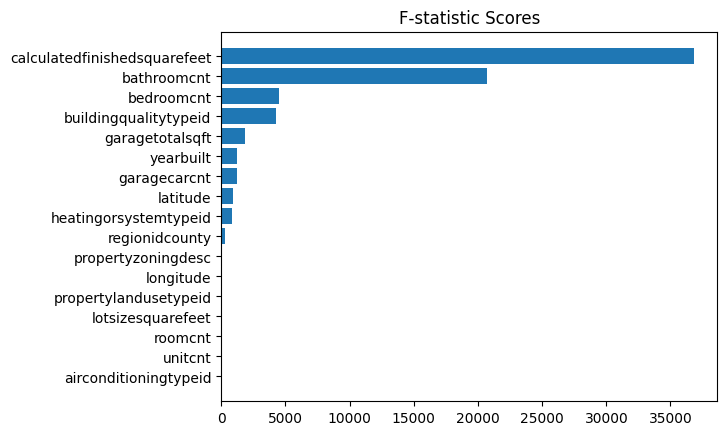

In [19]:
# =============================
# 2. F-statistic 
# =============================
f_values, p_values = f_regression(X, y)

f_df_4a = pd.DataFrame({
    'feature': X.columns,
    'f_score': f_values
}).sort_values(by='f_score', ascending=False)

print("\nF-statistics:")
print(f_df_4a)

# Bar chart
plt.figure()
plt.barh(f_df_4a['feature'], f_df_4a['f_score'])
plt.title("F-statistic Scores")
plt.gca().invert_yaxis()
plt.show()



In [20]:
from sklearn.linear_model import LinearRegression

# =============================
# 3. Forward Feature Selection
# =============================
model = LinearRegression()

forward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='forward'
)

forward_selector.fit(X, y)
forward_features = X.columns[forward_selector.get_support()]

print("\nForward Selected Features:")
print(list(forward_features))

# =============================
# 4. Backward Feature Selection
# =============================
backward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='backward'
)

backward_selector.fit(X, y)
backward_features = X.columns[backward_selector.get_support()]

print("\nBackward Selected Features:")
print(list(backward_features))


Forward Selected Features:
['bathroomcnt', 'bedroomcnt', 'calculatedfinishedsquarefeet', 'latitude', 'longitude']

Backward Selected Features:
['bedroomcnt', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'roomcnt']


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



**4.A Answer**

The feature relationship analysis reveals consistent and interpretable patterns across multiple methods. The **correlation matrix** indicates that *calculatedfinishedsquarefeet* has the strongest linear relationship with the target (r ≈ 0.58), suggesting a substantial proportion of variance in property value is explained by **property size**. Other features such as *bathroomcnt* (r ≈ 0.48) and *bedroomcnt* (r ≈ 0.25) show moderate positive correlations, indicating additional explanatory power but also potential **multicollinearity** among size-related features. This is expected since <u>larger homes tend to have more bedrooms and bathrooms</u>, meaning these variables capture <u>similar underlying characteristics</u>. **Multicollinearity** can negatively impact some models (especially **linear regression**) by making coefficient estimates unstable, so this will need to be addressed in Milestone 2, either through model selection (for example: tree-based models like Random Forest that are less sensitive) or feature selection techniques.

The **F-statistic** analysis further reinforces these findings, as it ranks features based on their ability to explain variance in the target via univariate linear regression. The extremely high F-scores for *calculatedfinishedsquarefeet* and *bathroomcnt* confirm their strong predictive relevance, while features such as *roomcnt*, *unitcnt*, and *airconditioningtypeid* exhibit near-zero F-scores, indicating minimal explanatory contribution.

Importantly, **forward feature selection** provides a multivariate perspective by <u>evaluating features in combination rather than isolation</u>. The selection of latitude and longitude alongside structural features suggests that location contributes additional predictive signal beyond what is captured by individual correlations, highlighting potential nonlinear or interaction effects not fully captured by pairwise correlation alone. In addition, **backward feature selection** was also explored, and both methods selected a **similar core set of features**, with the main differences occurring among **size-related variables** that are themselves **highly colinear**. This further supports the earlier observation about **multicollinearity**. Notably, both methods consistently included *latitude* and *longitude*, reinforcing the importance of <u>location</u> as a key factor in predicting property value

While the correlation matrix and F-statistic (both univariate measures) largely agree on feature importance rankings, forward selection demonstrates that features with weaker individual correlations can still improve model performance when combined with others. Overall, the methods are largely consistent in identifying the most informative features, but they differ in that univariate techniques measure isolated relationships, whereas sequential feature selection captures joint predictive contributions and interactions, providing a more holistic view of feature importance.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

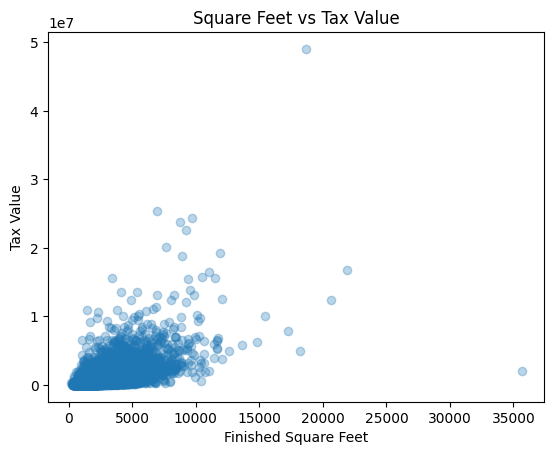

In [21]:

df_4b = df_4a.copy()

# =============================
# 1. Pair 1: Size vs Target
# =============================
plt.figure()
plt.scatter(df_4b['calculatedfinishedsquarefeet'], df_4b['taxvaluedollarcnt'], alpha=0.3)
plt.xlabel('Finished Square Feet')
plt.ylabel('Tax Value')
plt.title('Square Feet vs Tax Value')
plt.show()



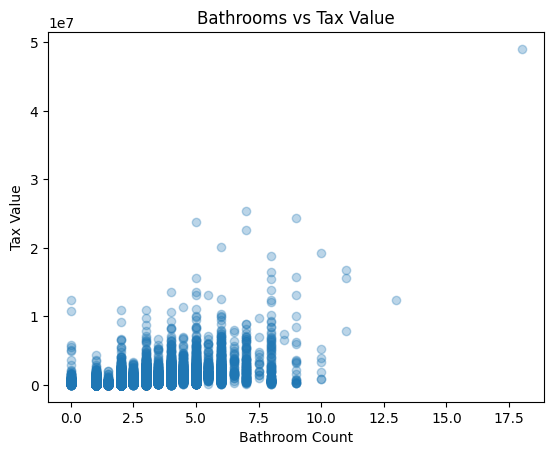

In [22]:
# =============================
# 2. Pair 2: Bathrooms vs Target
# =============================
plt.figure()
plt.scatter(df_4b['bathroomcnt'], df_4b['taxvaluedollarcnt'], alpha=0.3)
plt.xlabel('Bathroom Count')
plt.ylabel('Tax Value')
plt.title('Bathrooms vs Tax Value')
plt.show()



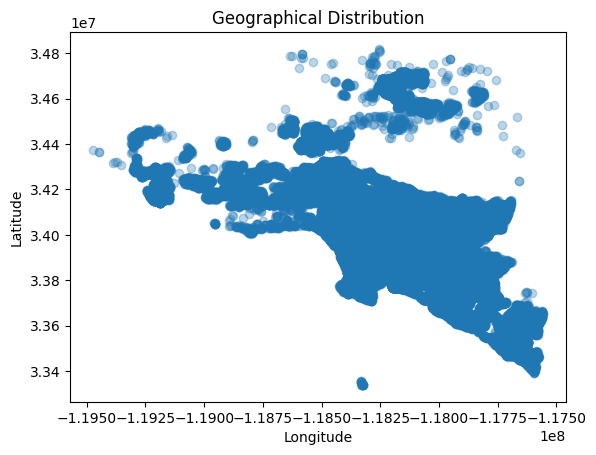

In [23]:
# ============================================================
# 3. Pair 3: Latitude vs Longitude (location clustering)
# ===========================================================
plt.figure()
plt.scatter(df_4b['longitude'], df_4b['latitude'], alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution')
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


**4.B Answer**

The 2D visualizations reveal several meaningful patterns in the relationships between features and the target variable. The scatter plot of *calculatedfinishedsquarefeet* vs. *taxvaluedollarcnt* shows a clear **positive relationship**, where property value generally increases with size. However, the relationship is <u>not perfectly linear</u>, as the variance in property value increases for larger homes, indicating <u>heteroscedasticity</u> and the presence of <u>outliers</u>, particularly among very large properties.

The plot of *bathroomcnt* vs. *taxvaluedollarcnt* also demonstrates a positive trend, but with a more discrete structure due to the integer nature of the feature. While higher bathroom counts are generally associated with higher property values, the spread of values within each category suggests that bathrooms alone are not sufficient to explain price variation, and that other factors such as size and location play a significant role.

The geographical scatter plot of *latitude* vs. *longitude* reveals clear **spatial clustering**, indicating that properties are concentrated in specific regions. This suggests that location is an important factor influencing property value, and that geographic features may capture regional effects such as neighborhood desirability. These clusters also imply potential **nonlinear relationships** between location and price, which may not be fully captured by simple linear models.

Overall, these visualizations confirm earlier findings from correlation and feature selection analyses: property size is the strongest predictor, structural features contribute moderately, and location introduces additional complexity through spatial patterns.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [24]:
# Copy the the dataset from the previous step
df_5 = df_4b.copy()

X = df_5.drop(columns=['taxvaluedollarcnt'])
y = df_5['taxvaluedollarcnt']

# =================================================
# 1. Method: Log Transformation
# =================================================
def add_log_features(df):
    df_log = df.copy()
    df_log['log_sqft'] = np.log1p(df_log['calculatedfinishedsquarefeet'])
    df_log['log_lotsize'] = np.log1p(df_log['lotsizesquarefeet'])
    return df_log

df_5_log = add_log_features(df_5)

X_log = df_5_log.drop(columns=['taxvaluedollarcnt'])
f_log, _ = f_regression(X_log, y)

log_results = pd.DataFrame({
    'feature': X_log.columns,
    'f_score': f_log
}).sort_values(by='f_score', ascending=False)

print("Top features after LOG transformation:")
print(log_results.head(8))

Top features after LOG transformation:
                         feature       f_score
4   calculatedfinishedsquarefeet  36800.019016
1                    bathroomcnt  20696.104185
17                      log_sqft  20139.698568
2                     bedroomcnt   4531.823269
3          buildingqualitytypeid   4289.546126
6                garagetotalsqft   1873.781496
16                     yearbuilt   1256.834590
5                   garagecarcnt   1203.765871


In [25]:
# ===================================================
# 2. Method: Interaction Features
# ====================================================
def add_interactions(df):
    df_int = df.copy()
    df_int['sqft_x_bath'] = df_int['calculatedfinishedsquarefeet'] * df_int['bathroomcnt']
    df_int['bed_bath_ratio'] = df_int['bedroomcnt'] / (df_int['bathroomcnt'] + 1)  # I added +1 to avoid dividing by zero
    return df_int

df_5_int = add_interactions(df_5)

X_int = df_5_int.drop(columns=['taxvaluedollarcnt'])
f_int, _ = f_regression(X_int, y)

int_results = pd.DataFrame({
    'feature': X_int.columns,
    'f_score': f_int
}).sort_values(by='f_score', ascending=False)

print("\nTop features after INTERACTION transformation:")
print(int_results.head(8))


Top features after INTERACTION transformation:
                         feature       f_score
17                   sqft_x_bath  50762.803992
4   calculatedfinishedsquarefeet  36800.019016
1                    bathroomcnt  20696.104185
2                     bedroomcnt   4531.823269
3          buildingqualitytypeid   4289.546126
6                garagetotalsqft   1873.781496
16                     yearbuilt   1256.834590
5                   garagecarcnt   1203.765871


In [26]:
# ================================================
# 3. Method: Feature Scaling
# =================================================
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

f_scaled, _ = f_regression(X_scaled, y)

scaled_results = pd.DataFrame({
    'feature': X.columns,
    'f_score': f_scaled
}).sort_values(by='f_score', ascending=False)

print("\nTop features after SCALING:")
print(scaled_results.head(8))


Top features after SCALING:
                         feature       f_score
4   calculatedfinishedsquarefeet  36800.019016
1                    bathroomcnt  20696.104185
2                     bedroomcnt   4531.823269
3          buildingqualitytypeid   4289.546126
6                garagetotalsqft   1873.781496
16                     yearbuilt   1256.834590
5                   garagecarcnt   1203.765871
8                       latitude    900.350237


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


**Answer**

The selected transformations were chosen to address key characteristics observed during exploratory data analysis (EDA), including **skewed distributions**, **potential nonlinear relationships**, and **differences in feature scale**. **Log transformations** were applied to features such as `calculatedfinishedsquarefeet` and `lotsizesquarefeet` because they exhibited strong **right-skewness** and contained **outliers**; this transformation helps **stabilize variance** and can improve linear model performance. However, the results showed that while the log-transformed features retained strong relationships with the target, they did **not outperform the original features**, suggesting that the raw variables already captured most of the predictive signal.

**Interaction features** were introduced to capture **nonlinear relationships** between variables, particularly the combination of property size and number of bathrooms. The engineered feature **`sqft_x_bath`** significantly increased the F-score and became the **most predictive feature**, indicating that **joint effects between features** provide additional explanatory power beyond individual variables.

Finally, **feature scaling** was applied to standardize the data, which is important for many machine learning algorithms, although it did **not affect statistical measures** such as correlation or F-scores. Overall, **interaction-based transformations** yielded the most meaningful improvement, highlighting the importance of modeling **relationships between features** rather than relying solely on individual predictors.



## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

